In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from matplotlib import pyplot as plt
from keras.models import model_from_json

In [2]:
# Load and preprocess the MNIST dataset
(train_x, train_y), (test_x, test_y) = keras.datasets.mnist.load_data()
train_x = train_x / 255.0
test_x = test_x / 255.0
print(train_x.shape)


(60000, 28, 28)


In [3]:
# Expand dimensions for channel compatibility
train_x = tf.expand_dims(train_x, -1)
test_x = tf.expand_dims(test_x, -1)
val_x = train_x[:5000]
val_y = train_y[:5000]
print(train_x.shape)

(60000, 28, 28, 1)


In [4]:
# Define the LeNet-5 model
lenet_5_model = keras.models.Sequential([
    keras.layers.Conv2D(6, kernel_size=5, strides=1,  activation='tanh', input_shape=train_x[0].shape, padding='same', name="C1"),
    keras.layers.AveragePooling2D(pool_size=2, name="S2"),
    keras.layers.Conv2D(16, kernel_size=5, strides=1, activation='tanh', padding='valid', name="C3"),
    keras.layers.AveragePooling2D(pool_size=2, name="S4"),
    keras.layers.Flatten(), #Flatten
    keras.layers.Dense(120, activation='tanh', name="F5"),
    keras.layers.Dense(84, activation='tanh', name="F6"),
    keras.layers.Dense(10, activation='softmax', name="F7")
])

C:\Users\NightFore\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# Compile the model
lenet_5_model.compile(
    optimizer='adam',
    loss=keras.losses.sparse_categorical_crossentropy,
    metrics=['accuracy']
)

In [6]:
# Train the model
lenet_5_model.fit(train_x, train_y, epochs=5, validation_data=(val_x, val_y))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.8719 - loss: 0.4218 - val_accuracy: 0.9744 - val_loss: 0.0847
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9715 - loss: 0.0945 - val_accuracy: 0.9870 - val_loss: 0.0563
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9807 - loss: 0.0609 - val_accuracy: 0.9892 - val_loss: 0.0352
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9870 - loss: 0.0425 - val_accuracy: 0.9886 - val_loss: 0.0403
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9899 - loss: 0.0333 - val_accuracy: 0.9916 - val_loss: 0.0306


In [7]:
# Evaluate the model on the test set
test_loss, test_accuracy = lenet_5_model.evaluate(test_x, test_y)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9782 - loss: 0.0678
Test Accuracy: 0.9822
Test Loss: 0.0557


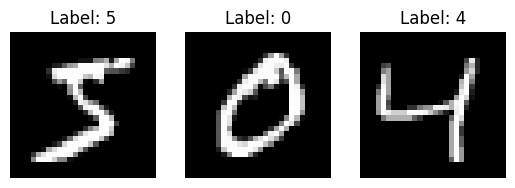

In [8]:
# Visualize some training images
for i in range(3):  
    plt.subplot(1, 3, 1 + i)
    plt.imshow(train_x[i], cmap=plt.get_cmap('gray'))
    plt.title(f"Label: {train_y[i]}")
    plt.axis('off')
plt.show()

In [9]:
# Create the directory if it does not exist
os.makedirs("data", exist_ok=True)

# Save the model in various formats
lenet_5_model.save('data/lenet_5_model.keras')
lenet_5_model.save("data/lenet_5_model.h5")

In [10]:
# Save the model architecture in JSON format
json_model = lenet_5_model.to_json()
with open('data/lenet_5_model.json', 'w') as json_file:
    json_file.write(json_model)

In [11]:
# Save the model weights in HDF5 format
lenet_5_model.save_weights('data/lenet_5_model.weights.h5')

In [12]:
# Model summary for inspection
lenet_5_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ C1 (Conv2D)                          │ (None, 28, 28, 6)           │             156 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ S2 (AveragePooling2D)                │ (None, 14, 14, 6)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ C3 (Conv2D)                          │ (None, 10, 10, 16)          │           2,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ S4 (AveragePooling2D)                │ (None, 5, 5, 16)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 400)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ F5 (Dense)                           │ (None, 120)                 │          48,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ F6 (Dense)                           │ (None, 84)                  │          10,164 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ F7 (Dense)                           │ (None, 10)                  │             850 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 185,120 (723.13 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 123,414 (482.09 KB)

In [18]:
# Extract and display the weights of the first Conv2D layer (C1)
weights_C1 = lenet_5_model.layers[0].get_weights()[0]  
print("Weights of the first Conv2D layer (C1):")
print(weights_C1)

# Extract and display the biases of the first Conv2D layer (C1)
biases_C1 = lenet_5_model.layers[0].get_weights()[1]  
print("\nBiases of the first Conv2D layer (C1):")
print(biases_C1)


Weights of the first Conv2D layer (C1):
[[[[ 2.52489820e-02  2.56215353e-02 -2.70107597e-01  2.03927979e-02
     3.71154875e-01 -1.13307208e-01]]

  [[-2.11957559e-01 -4.04065773e-02 -3.50262821e-01 -1.94419995e-01
     3.95678520e-01 -2.81101257e-01]]

  [[-3.30425888e-01  1.08007841e-01 -4.81862500e-02 -2.12213114e-01
     3.15977901e-01 -4.73882467e-01]]

  [[-1.56321079e-01  1.15387306e-01  9.77538675e-02 -2.33437836e-01
     1.22298256e-01 -3.72483760e-01]]

  [[ 7.03487545e-02  3.06313902e-01  3.19285899e-01 -6.15828335e-02
     2.05372155e-01  4.77166846e-02]]]


 [[[-6.05975278e-02  9.52397436e-02 -1.24815861e-02 -4.00056690e-01
     2.61724591e-01 -1.79106519e-01]]

  [[-5.39446592e-01  2.67068356e-01 -8.28587934e-02 -5.98768890e-01
    -4.81175259e-02 -4.27734494e-01]]

  [[-3.86952519e-01  2.43896633e-01  3.12578022e-01 -6.17107809e-01
    -1.48996692e-02 -7.50957072e-01]]

  [[-4.05795537e-02  2.66142040e-01  6.23470485e-01 -2.12388933e-01
     2.14972436e-01 -4.95747924e-0

In [20]:
def save_model_weights_to_files(model, output_dir):
    """
    Extracts weights and biases from a trained model and saves them to separate text files.

    Args:
        model: The trained TensorFlow/Keras model.
        output_dir: Directory where the weights and biases will be saved.
    """
    # Ensure the output directory exists
    os.makedirs(output_dir, exist_ok=True)

    for layer in model.layers:
        # Get the weights and biases for the layer
        weights = layer.get_weights()

        # Some layers may not have weights
        if weights:
            # Weights are always the first element
            weight_array = weights[0]
            flat_weights = weight_array.flatten()

            # Save weights
            weight_file = os.path.join(output_dir, f"{layer.name}_weights.txt")
            with open(weight_file, "w") as f:
                f.write(" ".join(map(str, flat_weights)))
                f.write("\n")
            print(f"Saved weights for layer '{layer.name}' to {weight_file}")
            
            # If biases exist
            if len(weights) > 1:
                # Biases are always the second element
                bias_array = weights[1]
                flat_biases = bias_array.flatten()

                # Save biases
                bias_file = os.path.join(output_dir, f"{layer.name}_biases.txt")
                with open(bias_file, "w") as f:
                    f.write(" ".join(map(str, flat_biases)))
                    f.write("\n")
                print(f"Saved biases for layer '{layer.name}' to {bias_file}")

# Save weights and biases separately into text files
save_model_weights_to_files(lenet_5_model, "data")


Saved weights for layer 'C1' to data\C1_weights.txt
Saved biases for layer 'C1' to data\C1_biases.txt
Saved weights for layer 'C3' to data\C3_weights.txt
Saved biases for layer 'C3' to data\C3_biases.txt
Saved weights for layer 'F5' to data\F5_weights.txt
Saved biases for layer 'F5' to data\F5_biases.txt
Saved weights for layer 'F6' to data\F6_weights.txt
Saved biases for layer 'F6' to data\F6_biases.txt
Saved weights for layer 'F7' to data\F7_weights.txt
Saved biases for layer 'F7' to data\F7_biases.txt
